# Uncertainties in Gaussian spectra

The goal of this notebook is to gather my thoughts about uncertainties in gaussian spectra, such as encountered in water waves in the ocean (though this will apply to any phenomenon that follows a stochastic gaussian process and is analyzed with a spectrum DFT based method). The demonstrations are not included, to keep the explanation short and readable - the goal is to give a "physicist's explanation" of what one's intuition and main things to keep in mind should be. Somehow, so far, either I was only finding too shallow / "beginner level" materials, or I was finding full detail textbook, nothing "in the middle" that I can read fast to refresh my mind, get all the information I need, but within just a few pages not a full book. This is what I attempt here.

For more information, see a course on DFT / signal analysis or just ask any AI - they know all of this very well. Typically, this assumes that one already has a diffuse understanding and knows the main notions, and just needs a straight easy-to-read self-contained main-points writeup. For more details / explanations / more advanced formula that are only mentioned not written, read a textbook or ask AI.

## A bit of theory

### Fundamentals of gaussian stochastic signals analysis with DFT / iDFT

We consider a physical phenomenon that follows a stochastic process, stationary over the sampling time considered, resulting in an observable time series $x(t)$, with $t$ the time. The phenomenon is sampled over discrete time samples $t_n$, $n=0..N-1$, equally spaced in time (spacing $dt$, sampling frequency $f_s = 1 / dt$) for simplicity, so $t_n=n dt$ and the total signal duration is $T = N dt$. The underlying stochastic process is unknown - all what we have access to, is an individual realization of the stochastic process, through the discrete time series samples of the $x(t_n)$. In the following, we write like a physicist, and sometimes we write $x_n$ (resp. $X_k$), sometimes we write $x(t_n)$ (resp. $X(f_k)$), referring to the value at a point in time or by index. The operators sending between time and frequency are written $\mathrm{DFT}$ and $\mathrm{iDFT}$. We write $\mathrm{var}(\cdot)$ for the variance (quadratic in the quantity) and $\sigma(\cdot)$ for the standard deviation (the square root of the variance, homogeneous in the quantity); these are not interchangeable.

Given the time series samples, one can build an estimator for the underlying stochastic process complex frequency coefficients (the "true" underlying process from which the individual time series realization is extracted is typically hidden and can never be observed) by using the discrete Fourier transform (DFT) estimator for frequency $f_k = k / T$ (as a note, this formula is only strictly valid for $k=0..\lfloor N/2 \rfloor$; for $k=\lfloor (N+1)/2 \rfloor..N-1$, the frequencies wrap, so the frequency effectively sampled is the negative frequency $f_k = (k-N) / T$):

$X(f_k) = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x(t_n) e^{-i 2 \pi k n / N}$, with $k=0..N-1$.

The inverse DFT (iDFT) is then:

$x(t_n) = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} X(f_k) e^{i 2 \pi k n / N}$, with $n=0..N-1$,

so that $\mathrm{iDFT} \circ \mathrm{DFT} = \mathrm{DFT} \circ \mathrm{iDFT} = \mathrm{Id}$, with $\mathrm{Id}$ the identity.

Note that the $x(t_n)$ and $X(f_k)$ are in general complex. In the case when $x$ is real, $X$ is hermitian, i.e. $X_k = X^*_{N-k \bmod N}$ (the $\bmod N$ covers the special case that $X_0$ is real, and that there is no $X_N$; when $N$ is even, $X_{N/2}$ is also real). This means one needs to remember to take moduli and consider both real and imaginary parts of both $x$ and $X$ as needed depending on the case considered.

The Parseval theorem guarantees to us that $\sum_{n=0}^{N-1} |x(t_n)|^2 = \sum_{k=0}^{N-1} |X(f_k)|^2$ . This means that, effectively, the DFT and iDFT with proper normalization conserve energy, and the signal $x$ shows the distribution of signal energy across time, while $X$ shows the distribution of signal energy across frequencies.

Note that the conventions on the DFT and inverse DFT (sign, normalization coefficients splitting between the DFT and iDFT, how the $N$ samples in time or frequency are stored as arrays and how the negative frequency are wrapped, specific behavior for real / hermitian inputs, etc) can change between textbooks / software packages etc: read the documentation of your package and have consistency tests! In this note we use *per-bin* energies ($\hat{S}_k = |X_k|^2$), so that Parseval is $\sum_n |x_n|^2 = \sum_k \hat{S}_k$. Some texts and packages instead quote a spectral *density* (energy per Hz), obtained from the per-bin quantity by dividing by $f_s$ (equivalently multiplying by $dt$); relative uncertainties are the same either way.

Using the DFT above, one can formulate a discrete estimator $\hat{S}$ for the underlying, hidden power spectrum of the stochastic process, called the periodogram, defined per bin as: $\hat{S}_k = |X_k|^2$. We write $S_k$ for the corresponding true bin powers ($\hat{S}_k$ estimates $S_k$). Note that $\hat{S}$ is only an estimator (see more about its properties below)!

Also note that there are "balances" / "equivalences" between how things are sampled in time and frequency: given $T = N dt$ the duration of the time series sampled, $N$ the number of sample points, $dt$ the sampling interval time, $f_s = 1 / dt$ the sampling rate, $df$ the DFT resolution:

- the highest frequency one can get an estimator for depends only on the sample rate (Nyquist frequency): $f_{max} = f_s / 2$
- the frequency resolution for the estimator depends only on the duration of the signal: $df = 1 / T$
- the number of DFT bins is $f_s / df = N$. The ratio $f_{max} / df = N/2$ is the number of bins from DC up to Nyquist. For a complex signal $x$, all $N$ bins are unique. For a real signal $x$, the DFT $X$ is hermitian, and there are only $N/2 + 1$ unique frequency bins (DC, positive frequencies, and Nyquist if $N$ is even).

In practice, the formula for the DFT and iDFT presented above are not how these are computed - these formula would be quadratic (complexity $\mathcal{O}(n^2)$ for computing the full array transform), while the discrete version of the fast Fourier transform (FFT) uses divide-and-conquer radix-based approaches to perform the same computation (implemented differently) in log-linear time (complexity $\mathcal{O}(n \log(n))$), with different prefactors depending on signal length and radix implementation - use a dedicated package, typically wrapping FFTW or similar!

### Uncertainties on the DFT spectrum estimator

Often, a goal in signal analysis is to estimate the power spectrum of a stochastic signal, and the periodogram $\hat{S}$ is used as an estimator (possibly with tapering, segmenting, and averaging - see the next section) for that. (In the continuous-time literature this spectrum is often the spectral *density*: the Fourier transform of the autocorrelation function. That density $S(f)$ is the per-bin $S_k$ divided by $f_s$; we stay per-bin.) As highlighted above, this is only an estimator, so it comes with uncertainties. In the following, we will consider that the underlying stochastic process is gaussian. This is generally a reasonable first approximation / model, as gaussianity naturally arises in many processes due to the central limit theorem (i.e., the average summation of very many independent identically distributed variables converges towards a gaussian distribution), though it may break down if some nonlinearity, coupling, etc, arises between the variables considered (for example, it is well established empirically that the stock market is usually log-normal, but this does not hold when a major event happens and individual stocks start responding in unison to a specific shock).

The periodogram $\hat{S}$ is asymptotically unbiased for the true underlying per-bin powers $S_k$ in the following sense:

$S_k = \lim_{T \to \infty} \mathbb{E} [\hat{S}_k]$ .

(If one normalizes to density, the same statement would read $f_s \cdot S(f_k) = \lim_{T \to \infty} \mathbb{E} [\hat{S}_k]$ with our $\hat{S}_k = |X_k|^2$, or equivalently one defines a density periodogram $|X_k|^2 / f_s$.)

This is a statement about the expectation, not about a single realization: as $T \to \infty$, $\mathrm{var}(\hat{S}_k)$ does not go to $0$, so the raw periodogram is not a consistent estimator. Note also that unbiasedness in this limit requires 2 ingredients that are challenging to reach in practice: i) the timeseries duration has to tend to infinity (which is challenging, as then the process usually does not remain stationary), ii) one has to consider the expected value, i.e. this holds for averaging over many realizations.

This highlights that $\hat{S}$ is only a stochastic estimator for the underlying per-bin spectrum $S$, which is asymptotically unbiased. Therefore, one needs to estimate the uncertainty associated with this estimator. Given that the underlying stochastic process is gaussian, the periodogram at each frequency bin is computed from the combination of the 2 real-valued coefficients (real part and imaginary part) obtained from the DFT:

$\hat{S}_k = a_k^2 + b_k^2$, where $a_k$ and $b_k$ are the real and imaginary part of the associated DFT output ($a_k = \mathrm{Re}(X_k)$, $b_k = \mathrm{Im}(X_k)$).

As the underlying stochastic process is gaussian, this means that taken individually, $a_k$ and $b_k$ follow a gaussian distribution. As a result, $\hat{S}_k$ follows a (scaled) chi-squared distribution with 2 degrees of freedom — except at the DC bin $k=0$ and, when $N$ is even, the Nyquist bin $k=N/2$, where $X_k$ is real and there is only 1 degree of freedom. The properties of the chi-squared distribution with 2 degrees of freedom are such that:

$\mathrm{var}(\hat{S}_k) = S_k^2$, hence $\sigma(\hat{S}_k) = S_k$. As $\hat{S}_k$ is our estimator for $S_k$, the estimator for $\mathrm{var}(\hat{S}_k)$ is $\hat{S}_k^2$, and the estimator for the standard deviation is $\hat{S}_k$ itself (relative uncertainty of $100\%$). Because this chi-squared (exponential) distribution is strongly skewed, a symmetric $\pm \sigma$ interval is a poor description of the uncertainty: $\hat{S}_k \pm \hat{S}_k$ is a Gaussian-style shorthand, not a confidence interval.

The usable statement comes from inverting the chi-squared law. In general (raw periodogram: $\nu=2$ at interior bins; $\nu=1$ at DC, and at Nyquist when $N$ is even)

$\hat{S}_k \sim S_k \cdot \chi^2_{\nu} / \nu$,

so $\nu \hat{S}_k / S_k \sim \chi^2_{\nu}$. A two-sided interval at level $1-\alpha$ is therefore

$S_k \in \left[ \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,1-\alpha/2}},\; \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,\alpha/2}} \right]$,

where $\chi^2_{\nu,q}$ is the $q$-quantile of $\chi^2_{\nu}$. The lower bound on $S_k$ uses the *upper* quantile of $\chi^2_{\nu}$, and conversely: that is just inverting $\nu \hat{S}_k / S_k$. For the raw periodogram ($\nu=2$, $\alpha=0.05$) this is about $[0.27\,\hat{S}_k,\, 39\,\hat{S}_k]$ — far from $\hat{S}_k \pm \hat{S}_k$. Averaging (next section) only changes $\nu$; the same formula applies. This means, in practice, that the estimator $\hat{S}$ comes with considerable uncertainty as a result of the nature of the underlying gaussian process, and how this estimator works. This explains why the DFT-based non-averaged periodogram of a timeseries that is a realization of a gaussian stochastic process is typically very "spiky".

### Tapering, segmenting and averaging, combining both in the Welch method estimator, and Welch periodogram uncertainty

#### Tapering

There are some additional assumptions that are implicitly baked into the analysis above. While the mathematics will work for any input signal provided as an array to the DFT or iDFT operator, these are typically discrete variants of the continuous Fourier transforms. These typically assume (to make the theory work) / work best (in practice) with periodic signals, and running these with a signal that is not periodic ($x_0 \neq x_{N-1}$) typically results in Gibbs-like oscillatory phenomenon / spectral leakage, meaning energy that should be concentrated in a specific bin, diffuses to neighboring bins.

To avoid this phenomenon, and since most real world signals are not truly periodic, one generally uses tapering: instead of computing:

$X = \mathrm{DFT}(x)$,

One computes:

$X^{(w)} = \mathrm{DFT}(w \cdot x)$, where $w$ is a tapering function (often called a "window" in DSP; here "window" in that sense means the taper, not a time segment). There are several tapering functions available, with different tradeoffs between in particular spectral leaking / amplitude accuracy, vs frequency resolution: typically, one cannot achieve at the same time high frequency resolution (getting narrow lobe where the energy is concentrated) and low spectral leaking (getting energy diffused into side lobes). See for example the tradeoffs between rectangular tapering (equivalent to no tapering), Hann, Hamming, Blackman-Harris, and more - depending on the application, one or another may offer a better tradeoff.

These tapering functions typically all look like "hats", which make the initial signal go smoothly (or not) to $0$ for the first and last index, while keeping the middle of the array unchanged. In practice, these are often available directly through software packages. How far the "hat" goes to zero at the left and right, the shape of the transitions, etc, is what decide the tradeoffs between different taperings.

#### Segmenting and averaging

A common way to reduce variance of an estimate is to perform averaging - the key result is that, averaging a random variable following a given distribution by sampling it independently $p$ times and doing an equally weighted average, reduces the variance by a factor $1/p$ compared to the individual variance of each sample (this works for any underlying distribution and is just simple arithmetics on the variance of the averaging formula). Said otherwise, the standard deviation of the independently-sampled, $p$-average estimator is $1/\sqrt{p}$ that of the 1-sample estimator. In addition, a second phenomenon takes place due to the central limit theorem: as $p$ is increased, the distribution followed by each $p$-averaged bin transitions from a chi-squared distribution (exact for a gaussian stochastic process and $p=1$), to a gaussian distribution (asymptotic behavior as $p \to \infty$). This happens gradually, and there are formula to quantify this convergence from chi-squared to Gaussian (exact formula for the skewness and kurtosis as a function of $p$, mathematical bounds on the CDF, mathematical expression for the KL divergence between the distribution of the average and the gaussian asymptote).

This can be effectively leveraged in cases when the signal is sampled for significantly longer than the autocorrelation time of the signal, by applying segmenting and averaging. For example, if the signal is split into $p$ independent non overlapping segments, and the DFT taken on each of these segments, then these periodograms averaged, the variance of each averaged bin estimate will be reduced by a factor $1/p$ (standard deviation $\sigma$ reduced by $1/\sqrt{p}$): $\sigma(\hat{S}^{(p)}) = \sigma(\hat{S}) / \sqrt{p} = \hat{S} / \sqrt{p}$. In addition, on average, with increasing $p$, the distribution will gradually move from a chi-squared towards a gaussian one.

To compute this in practice, one could naively compute the chi-squared distribution with 2 degrees of freedom, and how it gradually changes with averaging. However, this would be quite painful (especially when combining with tapering, see the Welch estimator). A better, and mathematically equivalent, method, is to observe that the periodogram averaged over $p$ segments for bin $i$ reads: $\hat{S}_i^{(p)} = \frac{1}{p} \sum_{k=0}^{p-1}( (a_i^k)^2 + (b_i^k)^2 )$, where $a_i^k$ is the real part of the DFT bin $i$ for the segment $k$, and $b$ the imaginary part. This follows a scaled chi-squared distribution with $\nu = 2p$ degrees of freedom: $\hat{S}_i^{(p)} \sim S_i \cdot \chi^2_{\nu} / \nu$. The confidence interval is the same formula as above, now with this $\nu$ (and $\mathrm{var}(\hat{S}_i^{(p)}) = \frac{2}{\nu} S_i^2 = S_i^2 / p$). Mathematically, everything is consistent, and the (scaled) chi-squared distribution converges to a gaussian distribution as the number of degrees of freedom grows to infinity, so this is equivalent to (and simpler than) the naive approach.

Note that increasing the length of the sample signal (remember the sample cannot be so long that the process is no longer stationary though!) and taking the DFT over the whole segment does not reduce the variance of the periodogram - it only increases the frequency resolution. To decrease the variance of the periodogram, one needs to perform averaging over segments, meaning that if this is made possible by gathering more consecutive samples, one keeps the same frequency resolution but reduces the variance. So, there is a tradeoff in the segmenting and averaging process, between frequency resolution and individual bin estimate variance.

This formula is only valid if consecutive non overlapping segments are independent. This is not the case if, for example, the process has memory over a time scale $\tau$ greater than the segment duration, which can be visible through the autocorrelation function not being uniformly close to $0$ for all time-lags greater than $\tau$. In such a case, the segments are not independent, and the variance reduces slower.

#### The Welch estimator

Tapering and segmenting-and-averaging are not mutually exclusive. Actually, they are usually combined, in what is called the "Welch method": cutting a signal into segments, for each segment apply a tapering function, and averaging the resulting periodograms.

In addition, tapering "washes out" the start and end of each segment, by down-weighting the samples therefrom. Therefore, these samples are not fully used by the tapered DFT, and one can gain more information "for free" by having overlap between the segments - intuitively, the left and right ends of a tapered segment are "under utilised", so overlapping tapered segments still have some level of "effective independence" available also on the overlapping array areas. One "simply" needs to compute the effective number of degrees of freedom per frequency bin and use it to formulate the relevant scaled chi-squared distribution. Note that the effective number of degrees of freedom depends on both the tapering function used, and the overlap fraction - there is a complex formula for this "variance scale factor", first derived by Peter Welch. For a Hann taper with 50% overlap, the tapering drops so fast that the overlap means each sample is "effectively nearly only used once", and the number of degrees of freedom per bin for $p$ segments is $\nu \approx \frac{36 p^2}{19 p - 1}$, which for large $p$ tends to $\frac{36}{19} p \approx 1.894 p$ (this approximation, due to Peter Welch, is already quite accurate even for small $p$, not just asymptotically). A larger overlap, or a tapering function that goes to 0 more slowly towards the edge of the segments, will result in a lower value for the number of degrees of freedom per bin as a function of $p$.

### Handling sensor noise

In real world applications, the measured series is the stochastic process plus sensor noise (possibly after a data fusion algorithm such as a Kalman filter). Independent Gaussian sensor noise does not add a second, "orthogonal" uncertainty on top of the periodogram $\chi^2$: it adds to the expected bin power, $S_k^{\mathrm{tot}} = S_k + N_k$, and the periodogram of the *measured* series still follows the scaled chi-squared of the previous sections, now with scale $S_k^{\mathrm{tot}}$:

$\hat{S}_k \sim S_k^{\mathrm{tot}} \cdot \chi^2_{\nu} / \nu$, hence $\mathrm{var}(\hat{S}_k) = \frac{2}{\nu} (S_k + N_k)^2$.

The noise floor $N_k$ can usually be identified separately. For example for MEMS acceleration sensors, the sensor datasheet provides the spectral noise *density* (per Hz); in this note's per-bin convention that density is multiplied by $f_s$ to get the corresponding bin power. In the case of a MEMS accelerometer, the acceleration noise is generally a constant, independent of frequency, so the per-bin floor is still a horizontal line. When combining accelerometer and gyroscope data feeds into a Kalman filter for attitude estimation, the resulting vertical acceleration effective filtered sensor noise level is usually still an horizontal support line in the acceleration spectrum, though it may be at a different level than that of the MEMS sensor datasheet taken alone, and it may depend on the "jitterness" of the ambient conditions and how this affects the Kalman filter internal state.

If $N_k$ is treated as known (datasheet or a fitted floor), it may be subtracted from $\hat{S}_k$ as a *bias correction* for the signal spectrum: $\hat{S}_k - N_k$ estimates $S_k$. Subtracting a constant does not reduce the variance. In particular, do *not* plug the noise-subtracted values into the chi-squared formulae ($\sigma = (\hat{S}-N)\sqrt{2/\nu}$ underestimates the uncertainty, badly when $S_k \lesssim N_k$; $\hat{S}-N$ is not chi-squared and can be negative). Use the same $\chi^2$ interval as above, but on the *total* periodogram (scale $S_k^{\mathrm{tot}} = S_k + N_k$), then subtract $N_k$:

$S_k \in \left[ \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,1-\alpha/2}} - N_k,\; \frac{\nu \hat{S}_k}{\chi^2_{\nu,\,\alpha/2}} - N_k \right]$.

Near the floor the relative uncertainty on $S_k$ blows up, and the interval may be clipped at $0$. When $S_k \gg N_k$ the correction is negligible.

Note that if plotting the spectrum in lin-lin scale, the error bars will change from bin to bin. But if plotting in semilogy scale, the error bars become a constant length "vertical cross" across the whole spectrum.

### Wrapping it up: how to do proper analysis of a stochastic gaussian process time-series

To wrap it up, the proper way to analyze a phenomenon that follows a simple gaussian process and obtain a periodogram estimate of its power spectrum, with uncertainty estimates, is to:

- gather the best data you can - best sensor possible, highest sampling rate and resolution and duration possible
- ensure that the data sample is actually following a gaussian process: plot the empirical distribution of samples and check that it is approximately gaussian at a reasonable significant statistical level (ideally with a proper statistical test, such as a Lilliefors / modified Kolmogorov-Smirnov test for a large number of samples)
- look at the autocorrelation function to determine the minimum time scale above which there is no significant autocorrelation in the signal - this typically sets the lower bound on the individual segments length; choose a segment length from there on
- as a sanity check, split the signal into such segments, and for each check the mean and standard deviation - check that they are generally stationary, or at least not too far from it
- choose a tapering window function depending on your goal and the resolution vs. leakage tradeoff
- choose a segment overlap factor - typically 50% or 75%
- apply the Welch method for estimating the periodogram
- determine the noise background $N_k$; for example for a MEMS-measured acceleration signal, this is obtained by looking for the "horizontal support line" in the periodogram
- compute the scaled chi-squared uncertainty on the *total* (signal + noise) periodogram, with the right number of degrees of freedom from the taper, overlap fraction, and number of segments
- only then subtract $N_k$ from the point estimate and from the confidence interval (do not apply $\chi^2$ to the noise-subtracted spectrum)
- remember that conventions, signs, normalizations of the DFT / iDFT can change between textbooks and software packages: read the documentation and have consistency tests

For several of these steps, there is no obvious choice - proceed by trial and error (but without doing cherry-picking!). Use common sense to double check results.

## An example: estimates applied for some waves in ice signals

### The data considered

These are the VN100 data for IMU VN1002 from a 20-minutes-ish-segment from "Observations of wave dispersion and attenuation in landfast ice", Sutherland and Rabault, 2016, https://doi.org/10.1002/2015JC011446 . The VN100 IMU combines accelerometer and gyroscope to do attitude estimation and get the vertical acceleration component in $m/s^2$. For more information, see the pdf online.

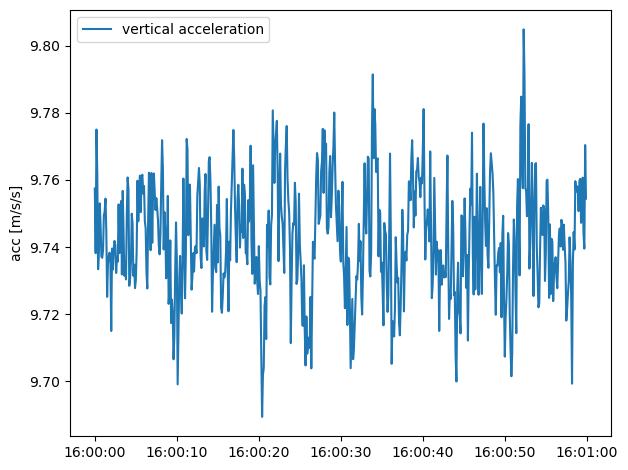

In [1]:
%reset -f

import polars as pl
import matplotlib.pyplot as plt

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)

fs = 10.0
ts = 1.0 / fs
n_points_plot = int(60 * fs)

plt.figure()
plt.plot(data["datetime"].to_numpy()[0:n_points_plot], data["VN1002_acc_d_m/s/s"].to_numpy()[0:n_points_plot], label="vertical acceleration")
plt.ylabel("acc [m/s/s]")
plt.legend()
plt.tight_layout()
plt.show()

### Quick look at data properties: Gaussian distribution

Note that there is a twist: for large real world samples, the Gaussian test becomes very powerful (very good at finding the smallest deviation from gaussianity), so it will usually fail in practice (find any slightly non gaussian deviation).

So in practice for large samples sizes, prefer looking at a Q-Q plot, and checking skewness and curtosis

A statistical test for normal distribution nearly always fail on large datasets


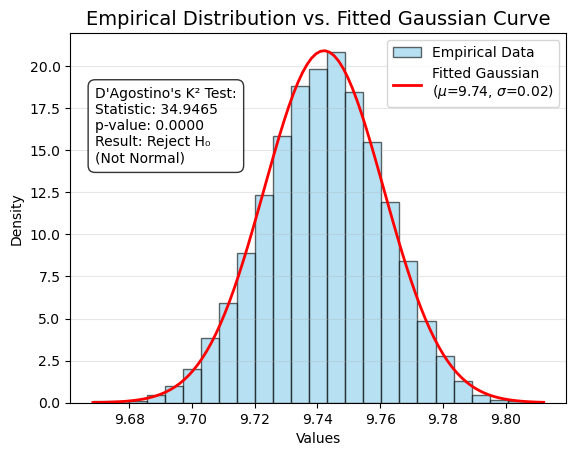


In practice, the data are near Gaussian


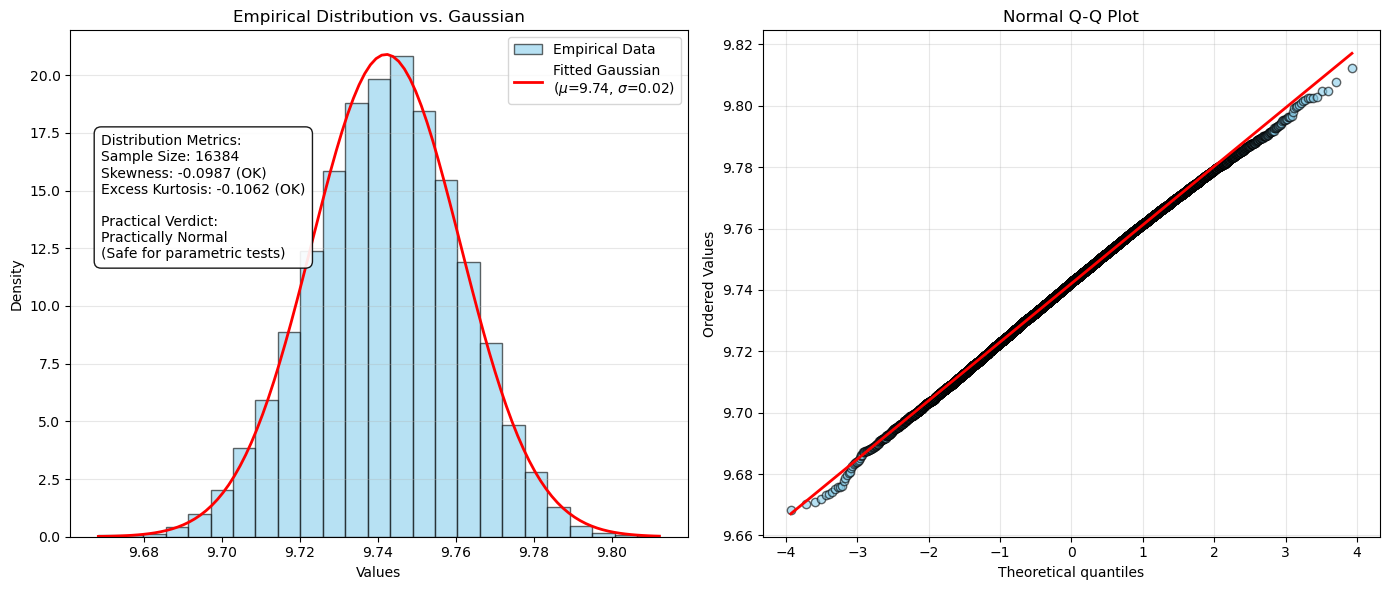

In [2]:
%reset -f

import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# ---

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()

# ---

print("A statistical test for normal distribution nearly always fail on large datasets")

mu, sigma = stats.norm.fit(data)
agostino_stat, p_value = stats.normaltest(data)

test_results = f"D'Agostino's K² Test:\nStatistic: {agostino_stat:.4f}\np-value: {p_value:.4f}\n"
if p_value > 0.05:
    test_results += "Result: Fail to reject H₀\n(Likely Normal)"
else:
    test_results += "Result: Reject H₀\n(Not Normal)"

x = np.linspace(min(data), max(data), 100)
gaussian_pdf = stats.norm.pdf(x, mu, sigma)

plt.figure()
count, bins, ignored = plt.hist(data, bins=25, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Empirical Data')
plt.plot(x, gaussian_pdf, 'r-', linewidth=2, label=f'Fitted Gaussian\n($\mu$={mu:.2f}, $\sigma$={sigma:.2f})')
plt.text(0.05, 0.65, test_results, transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
plt.title('Empirical Distribution vs. Fitted Gaussian Curve', fontsize=14)
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# ---

print("")
print("In practice, the data are near Gaussian")

mu, sigma = stats.norm.fit(data)
skewness = stats.skew(data)
ex_kurtosis = stats.kurtosis(data)

is_skew_ok = -1.0 <= skewness <= 1.0
is_kurt_ok = -2.0 <= ex_kurtosis <= 2.0

shape_results = (
    f"Distribution Metrics:\n"
    f"Sample Size: {len(data)}\n"
    f"Skewness: {skewness:.4f} ({'OK' if is_skew_ok else 'High'})\n"
    f"Excess Kurtosis: {ex_kurtosis:.4f} ({'OK' if is_kurt_ok else 'High'})\n\n"
    f"Practical Verdict:\n"
)
if is_skew_ok and is_kurt_ok:
    shape_results += "Practically Normal\n(Safe for parametric tests)"
else:
    shape_results += "Non-Normal Shape\n(Consider transformations)"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Left Subplot: Histogram + Fit
count, bins, ignored = ax1.hist(
    data,
    bins=25,
    density=True,
    alpha=0.6,
    color="skyblue",
    edgecolor="black",
    label="Empirical Data",
)
x = np.linspace(min(data), max(data), 100)
ax1.plot(
    x,
    stats.norm.pdf(x, mu, sigma),
    "r-",
    linewidth=2,
    label=f"Fitted Gaussian\n($\mu$={mu:.2f}, $\sigma$={sigma:.2f})",
)
ax1.text(
    0.05,
    0.55,
    shape_results,
    transform=ax1.transAxes,
    bbox=dict(facecolor="white", alpha=0.9, boxstyle="round,pad=0.5"),
)
ax1.set_title("Empirical Distribution vs. Gaussian", fontsize=12)
ax1.set_xlabel("Values")
ax1.set_ylabel("Density")
ax1.legend(loc="upper right")
ax1.grid(axis="y", alpha=0.3)

# Right Subplot: Q-Q Plot
stats.probplot(data, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor("skyblue")
ax2.get_lines()[0].set_markeredgecolor("black")
ax2.get_lines()[0].set_alpha(0.6)
ax2.get_lines()[1].set_color("red")
ax2.get_lines()[1].set_linewidth(2)
ax2.set_title("Normal Q-Q Plot", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Quick look at data properties: autocorrelation

Note that for a narrow band signal, one will always observe some weak "correlation echoes" at mutliples of the main band; typically, there is no significant autocorrelation after it has been to near-0 and shows only small ripples afterwards.

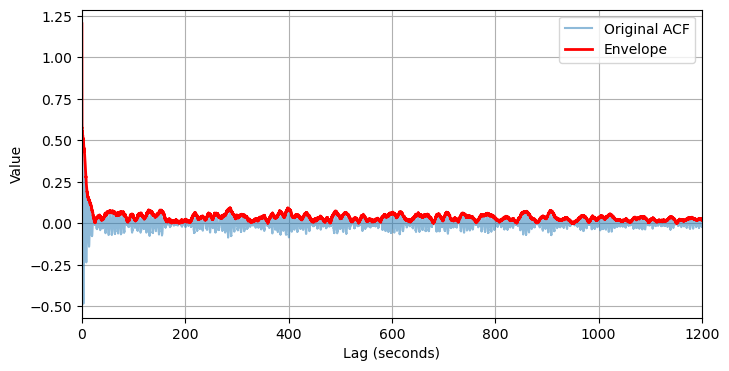

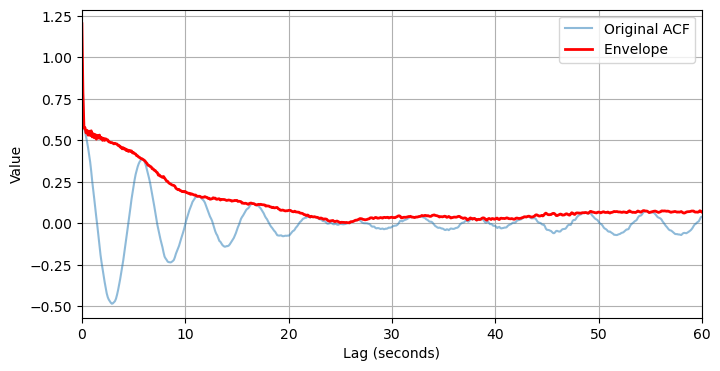

In [3]:
%reset -f

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0

data_centered = data - np.mean(data)
acf = np.correlate(data_centered, data_centered, mode='full')[len(data)-1:]
normalized_acf = acf / acf[0]

lags_time = np.arange(len(normalized_acf)) / fs

analytic_signal = hilbert(normalized_acf)
amplitude_envelope = np.abs(analytic_signal)

plt.figure(figsize=(8, 4))
plt.plot(lags_time, normalized_acf, label='Original ACF', alpha=0.5)
plt.plot(lags_time, amplitude_envelope, label='Envelope', color='red', linewidth=2)
plt.xlabel("Lag (seconds)")
plt.ylabel("Value")
plt.legend()
plt.xlim([0, 1200])
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lags_time, normalized_acf, label='Original ACF', alpha=0.5)
plt.plot(lags_time, amplitude_envelope, label='Envelope ', color='red', linewidth=2)
plt.xlabel("Lag (seconds)")
plt.ylabel("Value")
plt.legend()
plt.xlim([0, 60])
plt.grid(True)
plt.show()

### Quick look at data properties: stationarity

Naturally, this is a bit noisy - but observer there are no trends; we took a window duration based on the number of points (for fast FFT radix 2), that is well above the 30 seconds from above - this is depending on the tradeoffs we want.

time window duration: 204.8 s.


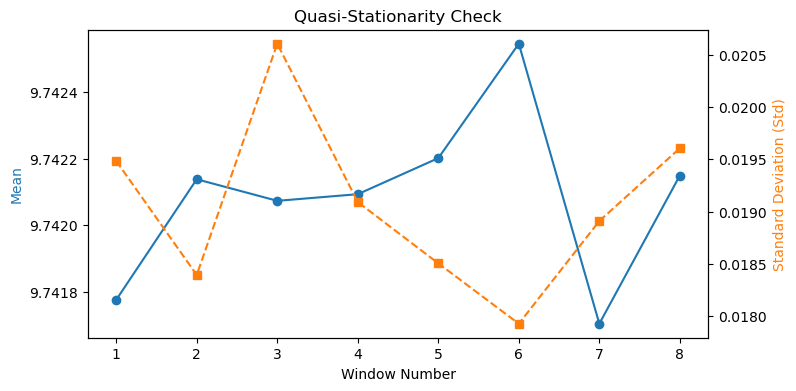

In [4]:
%reset -f

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0
win_dur = len(data) / 2**3 / fs

print(f"time window duration: {win_dur} s.")

win_samples = int(win_dur * fs)
num_wins = len(data) // win_samples
windows = data[:num_wins * win_samples].reshape(num_wins, win_samples)

means = np.mean(windows, axis=1)
stds = np.std(windows, axis=1)
x = np.arange(1, num_wins + 1)

# 3. Plot the metrics
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(x, means, 'o-', color='tab:blue', label='Mean')
ax2.plot(x, stds, 's--', color='tab:orange', label='Std')

ax1.set_xlabel('Window Number')
ax1.set_ylabel('Mean', color='tab:blue')
ax2.set_ylabel('Standard Deviation (Std)', color='tab:orange')
plt.title('Quasi-Stationarity Check')
plt.show()

### Welch estimator

We are now ready to do a Welch estimate, with error bars. The noise level is obtained as a combination of the accelerometer built-in the VN100 and the Kalman filtering run on the fly, so it does not match the "individual accelerometer datasheet", but we estimate it visually from the plot. As is visible here, the main and secondary (harmonic) lobes are clearly well resolved and real: they are both well above the noise level of the measurements taking into account the error bars.

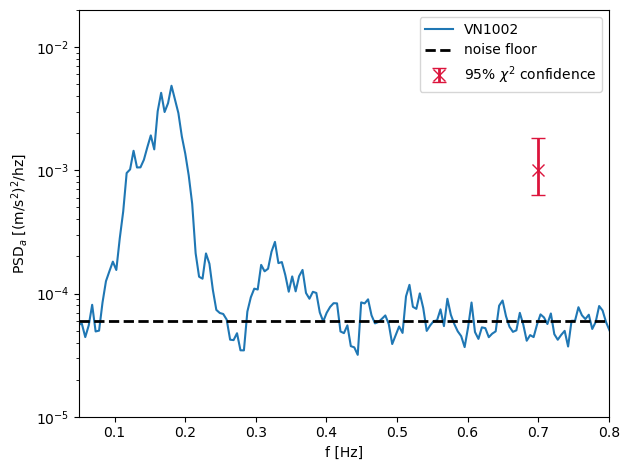

In [6]:
%reset -f

import polars as pl
import matplotlib.pyplot as plt
from scipy import signal
import scipy.stats as stats
import numpy as np

data = pl.read_csv("./segment_3.csv", try_parse_dates=True)
data = data["VN1002_acc_d_m/s/s"].to_numpy()
fs = 10.0

window = "hann"
nperseg = int(len(data) / 2**3)
noverlap = int(nperseg / 2)  # 50% overlap
nfft = nperseg
detrend = "constant"
return_onesided = True
scaling = "density"
average = "mean"
p = (len(data) - noverlap) // (nperseg - noverlap)
edf = (36 / 19) * p

crrt_f, crrt_welch_psd_acc_d = signal.welch(
    data,
    fs=fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
    nfft=nfft,
    detrend=detrend,
    return_onesided=return_onesided,
    scaling=scaling,
    average=average
)

alpha = 0.05
lower_chi = stats.chi2.ppf(alpha / 2, df=edf)
upper_chi = stats.chi2.ppf(1 - alpha / 2, df=edf)
scale_lower = edf / upper_chi
scale_upper = edf / lower_chi

plt.figure()
plt.plot(crrt_f, crrt_welch_psd_acc_d, label="VN1002")
plt.axhline(6e-5, color="black", linewidth=2.0, linestyle="--", label="noise floor")

x_cross = 0.7        
y_cross = 1e-3

y_err_lower = y_cross - (y_cross * scale_lower)
y_err_upper = (y_cross * scale_upper) - y_cross
y_err = [[y_err_lower], [y_err_upper]]

plt.errorbar(x_cross, y_cross, yerr=y_err, fmt='x', color='crimson', 
             markersize=8, capsize=5, elinewidth=2, label=f'95% $\chi^2$ confidence')

plt.xlim([0.05, 0.8])
plt.ylim([1e-5, 2e-2])

plt.xlabel("f [Hz]")
plt.ylabel("PSD$_a$ [(m/s$^2$)$^2$/hz]")
plt.legend()

plt.semilogy()
plt.tight_layout()
plt.show()